# **LCPB 25-26 Exercise 4, Clustering (DBSCAN)**


Group 2601
* Andreacchio Pasquale 2196577
* Calcagni Matteo Renato 2196575
* Gonzati Agostina 2188428
* Lavarda Nicola 2198664


In [15]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter
plt.rcParams['font.size'] = 12

# manifold.TSNE
from sklearn import manifold  #, datasets
from time import time

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from sklearn.cluster import KMeans


## Data and labels 
In this example we know the labels, hence we can test the performances of t-SNE and DBSCAN

In [3]:
fname,fnamey="x_12d.dat","y_12d.dat" 
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)
N=len(data) #number of data points
D=len(data[0]) #number of features
print("N=",N,"  L=D=",D)
x=data

N= 600   L=D= 12


## Important functions for the following tasks

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
cpalette = ["blue","red","gold","black","magenta","green","cyan","#1CE6FF", "#FF34FF", "#FF4A46","#008941", "#006FA6", "#A30059", "#0000A6", "#63FFAC","#B79762", "#004D43", "#8FB0FF", "#997D87","#5A0007", "#809693","#1B4400", "#4FC601", "#3B5DFF", "#4A3B53","#886F4C","#34362D", "#B4A8BD", "#00A6AA", "#452C2C","#636375", "#A3C8C9", "#FF913F", "#938A81","#575329", "#00FECF", "#B05B6F"]
from collections import OrderedDict
from itertools import product

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

# Normalized mutual information function
# Note that this deals with the label permutation problem
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

## **Task 1**

### k-distance plot
To choose the optimal `eps` for a given `minPts` (m_P), we look at the distance to the $m_P$-th nearest neighbor. A sharp increase (elbow) in the ranked distance plot indicates an optimal `eps` value.

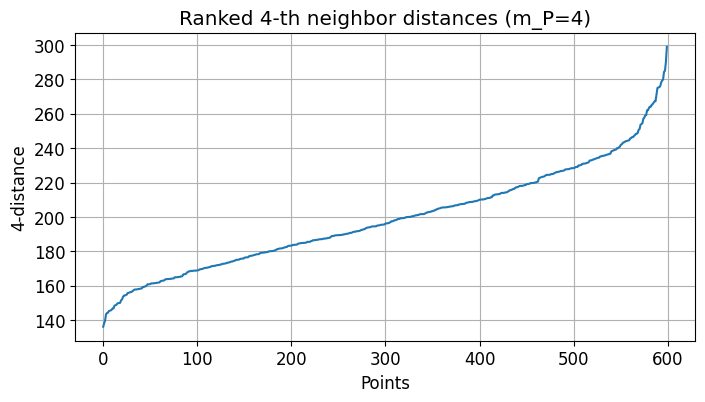

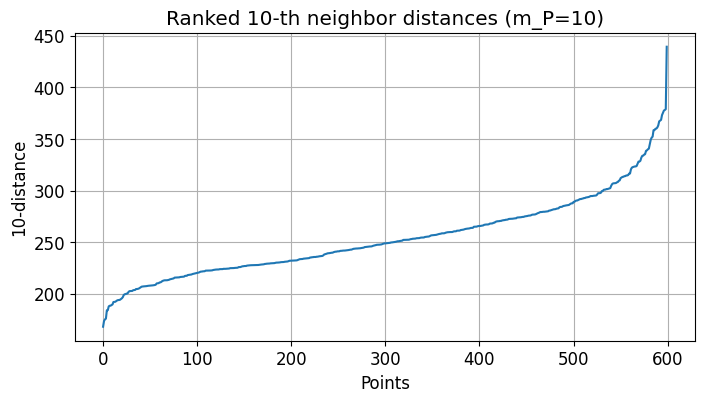

In [5]:
from sklearn.neighbors import NearestNeighbors

def plot_k_distance(data, k):
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(data)
    distances, _ = nbrs.kneighbors(data)
    distances = np.sort(distances[:, k-1], axis=0)
    
    plt.figure(figsize=(8, 4))
    plt.plot(distances)
    plt.title(f"Ranked {k}-th neighbor distances (m_P={k})")
    plt.xlabel("Points")
    plt.ylabel(f"{k}-distance")
    plt.grid(True)
    plt.show()

plot_k_distance(x, k=4)
plot_k_distance(x, k=10)

In [6]:
import pandas as pd 
import seaborn as sns

# DBSCAN parameter sweep refinement
np.random.seed(12345)

X = data
y_true = y

# Refined ranges for eps and min_samples (m_P)
# Following the image, we check a wider range
eps_range = np.arange(10, 361, 20)
min_sample_range = np.arange(1, 51, 2)

eps_mp_grid = np.array(list(product(eps_range, min_sample_range)))
nmi = []

print(f"Searching over {len(eps_mp_grid)} combinations...")
for value in eps_mp_grid:
    model = DBSCAN(eps=float(value[0]), min_samples=int(value[1]))
    model.fit(X)
    y_hat = model.labels_
    nmi.append(NMI(y_hat, y_true))

eps_mp_nmi_df = pd.DataFrame(
    data={
        "epsilon": eps_mp_grid[:,0], 
        "mp": eps_mp_grid[:,1],
        "nmi": nmi
    }
)

Searching over 450 combinations...


[Text(0.5, 1.0, 'NMI heatmap')]

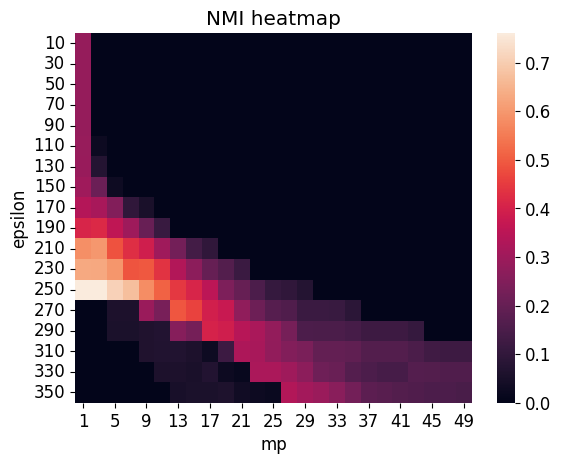

In [7]:
ax = sns.heatmap(
    data=eps_mp_nmi_df.pivot(index="epsilon", columns="mp", values="nmi"), 
    fmt='%1.2f'
)

ax.set(title = "NMI heatmap")

# Task 1 Questions

### Is the high NMI region showing a correlation between $\epsilon$ and $m_P$?
Yes, the heatmap clearly shows a positive (diagonal) correlation between $\epsilon$ and $m_P$. As $m_P$ (the minimum density required to form a cluster) increases, the radius $\epsilon$ must also increase proportionally to maintain a high NMI value.

Specific observation: The peak NMI region (light color, ~0.75) starts around $\epsilon \approx 250$ for low $m_P$ values and shifts towards higher $\epsilon$ as $m_P$ grows, following a well-defined diagonal band.

### How does the optimal value for $\epsilon$ given $m_P$ relate to the ranked distances?
The optimal $\epsilon$ value corresponds to the "elbow" or "knee" zone in the ranked distance plots:

For $m_p=4$, the heatmap indicates an optimal NMI in the range $\epsilon \in [210, 250]$. In the 4-distance plot, this range matches the exact point where the curve begins its steep ascent (around point 500-550 on the x-axis).
For $m_p=10$, the optimum shifts slightly higher ($\epsilon \approx 250-270$), which in the 10-distance plot again represents the transition zone before the final exponential growth.
Conclusion: The ranked distance plot is an excellent indicator for narrowing down the $\epsilon$ search space, as optimal values are found where neighbor distances stop being "flat" (points inside clusters) and start increasing (border or noise points).

## Task 2: PCA for understanding 12-dimensional data

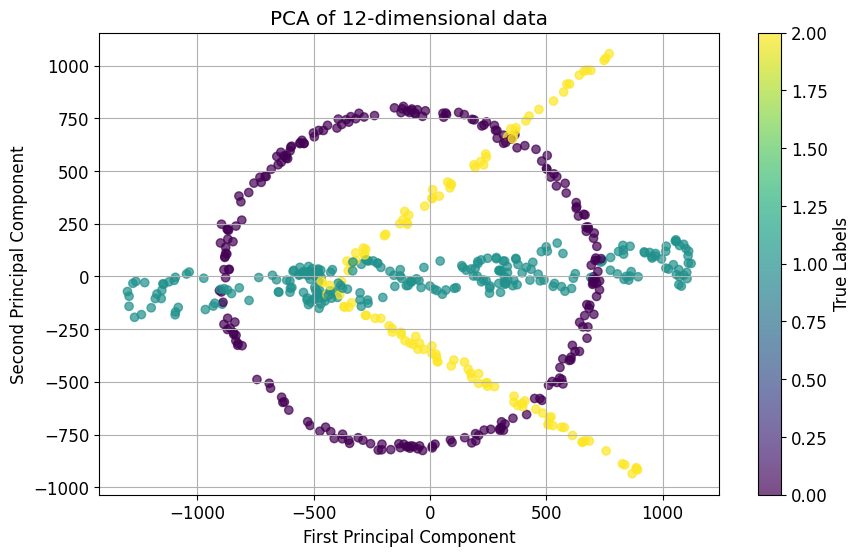

Explained variance ratio: [0.56042245 0.30928563]
Total explained variance (2 components): 0.87


In [8]:
from sklearn.decomposition import PCA

# PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='True Labels')
plt.title("PCA of 12-dimensional data")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.grid(True)
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance (2 components): {sum(pca.explained_variance_ratio_):.2f}")

# Task 2 Questions

### Does PCA help understand its structure?
Yes, PCA is extremely effective for this dataset. Despite reducing the dimensions from 12 to 2, it reveals a complex and non-trivial geometric structure:

The data points are not simple spherical "clouds" but are arranged along distinct manifold structures: a large outer ring (purple points), "spoke-like" or diagonal lines (yellow points), and central wave-like or cycloid patterns (teal points).
PCA confirms that the three clusters are well-separated in space but possess non-convex shapes, explaining why a density-based algorithm like DBSCAN is more suitable than models assuming spherical clusters (like standard k-means).

## Task 3: Compare with k-means

In [21]:
#k-means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)
nmi_kmeans = NMI(y, y_kmeans)
print(f"Normalized Mutual Information (NMI) for k-means: {nmi_kmeans:.4f}")

# t-SNE
# t-SNE with default perplexity=30
tsne = manifold.TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

#Best DBSCAN from grid search 
best_idx = eps_mp_nmi_df['nmi'].idxmax()
best_row = eps_mp_nmi_df.loc[best_idx]
nmi_dbscan_best = best_row['nmi']
best_eps = best_row['epsilon']
best_mp = int(best_row['mp'])
y_dbscan = DBSCAN(eps=best_eps, min_samples=best_mp).fit_predict(X)

print(f"Best DBSCAN NMI: {nmi_dbscan_best:.4f} (eps={best_eps}, mP={best_mp})")
print(f"k-means NMI:     {nmi_kmeans:.4f}")
print(f"DBSCAN Improvement:     {nmi_dbscan_best - nmi_kmeans:.4f}")

Normalized Mutual Information (NMI) for k-means: 0.1262
Best DBSCAN NMI: 0.7608 (eps=250.0, mP=1)
k-means NMI:     0.1262
DBSCAN Improvement:     0.6346


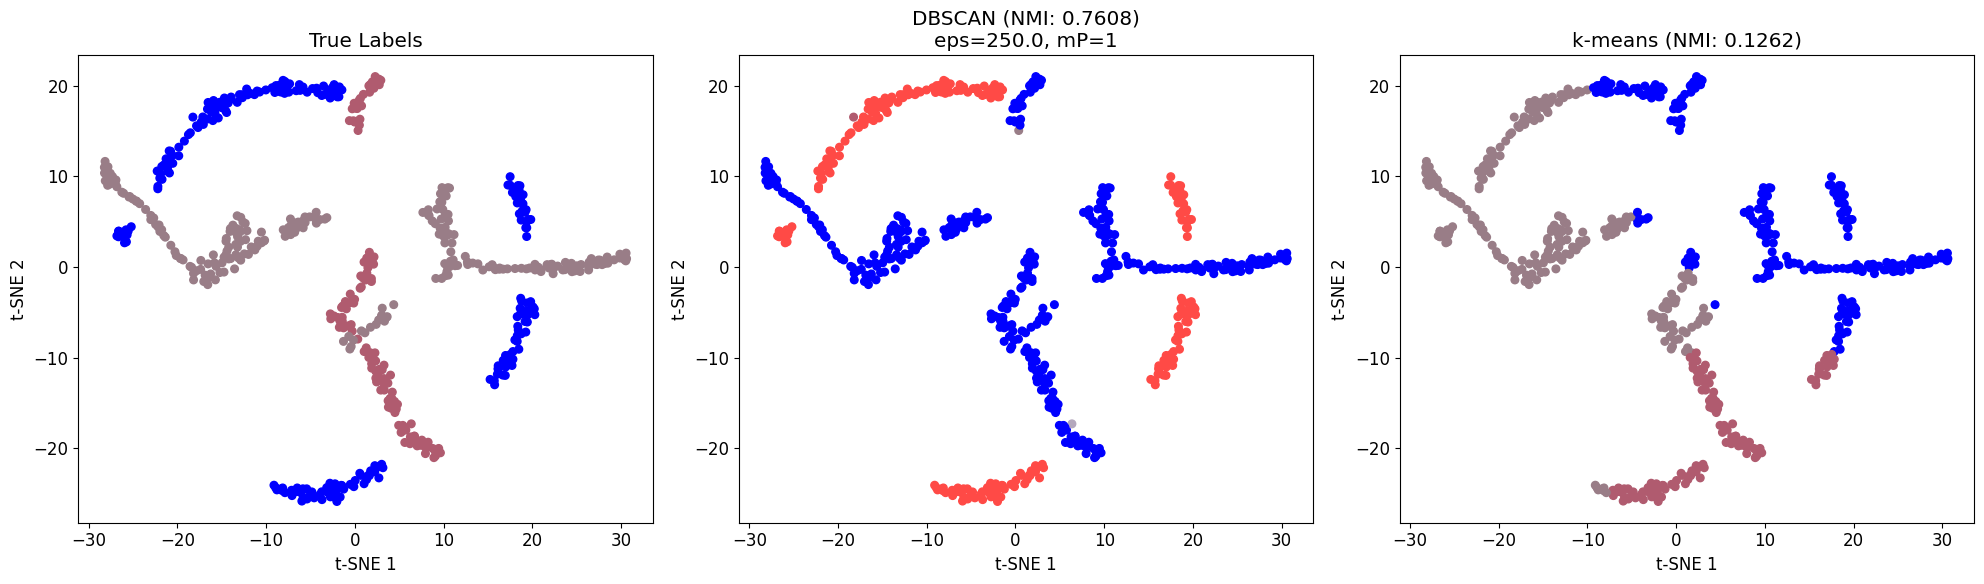

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap=ListedColormap(cpalette), s=30)
ax[0].set_title("True Labels")
ax[0].set_xlabel("t-SNE 1")
ax[0].set_ylabel("t-SNE 2")

ax[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y_dbscan, cmap=ListedColormap(cpalette), s=30)
ax[1].set_title(f"DBSCAN (NMI: {nmi_dbscan_best:.4f})\neps={best_eps}, mP={best_mp}")
ax[1].set_xlabel("t-SNE 1")
ax[1].set_ylabel("t-SNE 2")

ax[2].scatter(X_tsne[:,0], X_tsne[:,1], c=y_kmeans, cmap=ListedColormap(cpalette), s=30)
ax[2].set_title(f"k-means (NMI: {nmi_kmeans:.4f})")
ax[2].set_xlabel("t-SNE 1")
ax[2].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


# Task 3 Questions

### Perform a k-means clustering of the data, with k=3. Does it work better than DBSCAN? Why?
The best DBSCAN configuration (ε=250.0, mP=1) achieved NMI = 0.7608, compared to k-means NMI = 0.1262 — a DBSCAN improvement of roughly +0.6346, confirming quantitatively that DBSCAN is far superior on this non-convex dataset.
The main reason is that k-means is a centroid-based algorithm that assumes clusters are spherical and convex. However, the 12-dimensional data contains complex manifold structures, like rings and waves, clearly visible in the PCA plot, that are inherently non-convex. While DBSCAN can follow these shapes by identifying regions of local density, k-means fails because it minimizes global variance, often cutting through the natural geometry of the clusters. Additionally, k-means is forced to assign every point to a cluster, whereas DBSCAN's ability to label low-density points as noise ensures a more accurate and robust reconstruction of the true data structure.
Note that mP=1 is an extreme case; among more robust configurations, high NMI values are still consistently achieved for ε≈250 with larger mP values, as visible in the heatmap.